In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
import shap
import joblib
from sklearn.model_selection import train_test_split

In [2]:
best_model = joblib.load(r'D:\IT\Python\sklearn\hotel-booking-project\models\xgb_model.joblib')
df = pd.read_csv(r'D:\IT\Python\sklearn\hotel-booking-project\data\processed_hotel_booking.csv')
X = df.drop("is_canceled", axis=1)
y = df['is_canceled']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [3]:
model = best_model.named_steps["model"]
prep = best_model.named_steps["prep"]

feature_names = prep.get_feature_names_out()
feature_names = [col.replace("num__", "").replace("cat__", "") for col in feature_names]
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

importance_df.head(20)

,feature,importance
247,deposit_type_Non Refund,0.497859
259,room_changed_0,0.059331
14,required_car_parking_spaces,0.042663
217,market_segment_Online TA,0.042575
168,country_PRT,0.018919
9,previous_cancellations,0.016042
246,deposit_type_No Deposit,0.012184
15,total_of_special_requests,0.010424
251,customer_type_Transient,0.009871
214,market_segment_Direct,0.008711


In [4]:
i = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring='roc_auc'
)

In [5]:
pd.Series(
    i.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

country                           0.085095
deposit_type                      0.073919
market_segment                    0.064041
lead_time                         0.043021
required_car_parking_spaces       0.037350
total_of_special_requests         0.030695
previous_cancellations            0.025948
arrival_date_year                 0.021037
room_changed                      0.020054
adr                               0.019882
customer_type                     0.019754
arrival_date_week_number          0.006414
booking_changes                   0.005317
hotel                             0.004597
previous_bookings_not_canceled    0.004432
arrival_date_month                0.002336
meal                              0.001962
total_nights                      0.001562
distribution_channel              0.001380
arrival_date_day_of_month         0.001346
assigned_room_type                0.001235
has_agent                         0.000848
days_in_waiting_list              0.000832
stays_in_we

In [24]:
import shap

explainer = shap.TreeExplainer(model)

X_transformed = prep.transform(X_test).toarray()


X_transformed = pd.DataFrame(
    X_transformed,
    columns=feature_names
)

print(X_transformed.shape)

shap_values = explainer(X_transformed)

(23878, 261)


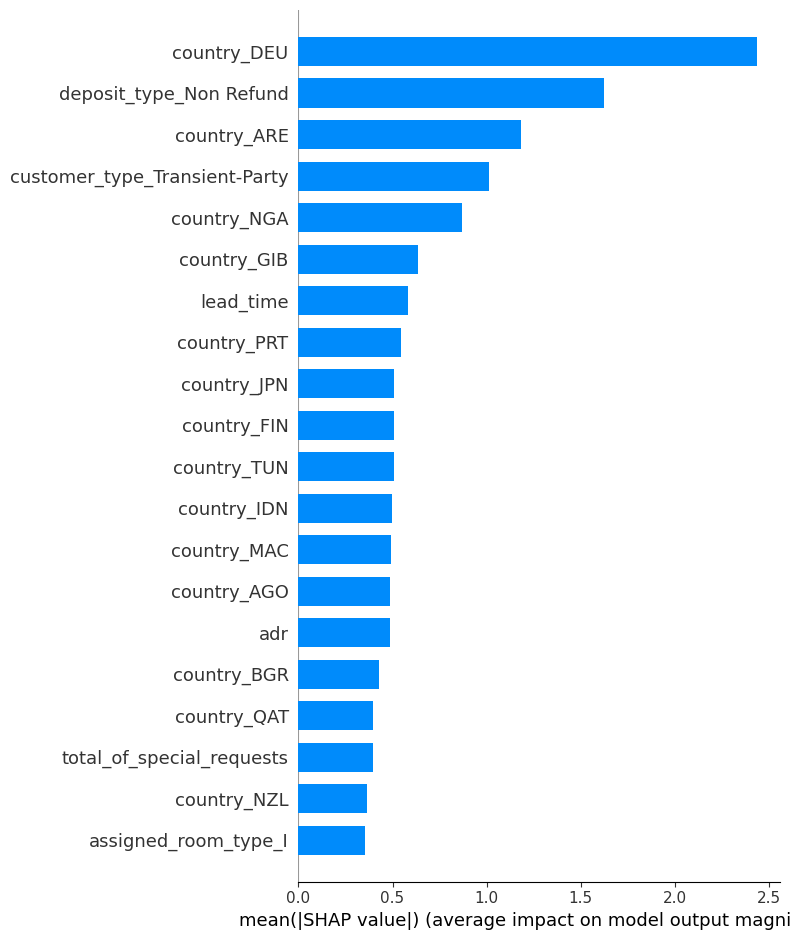

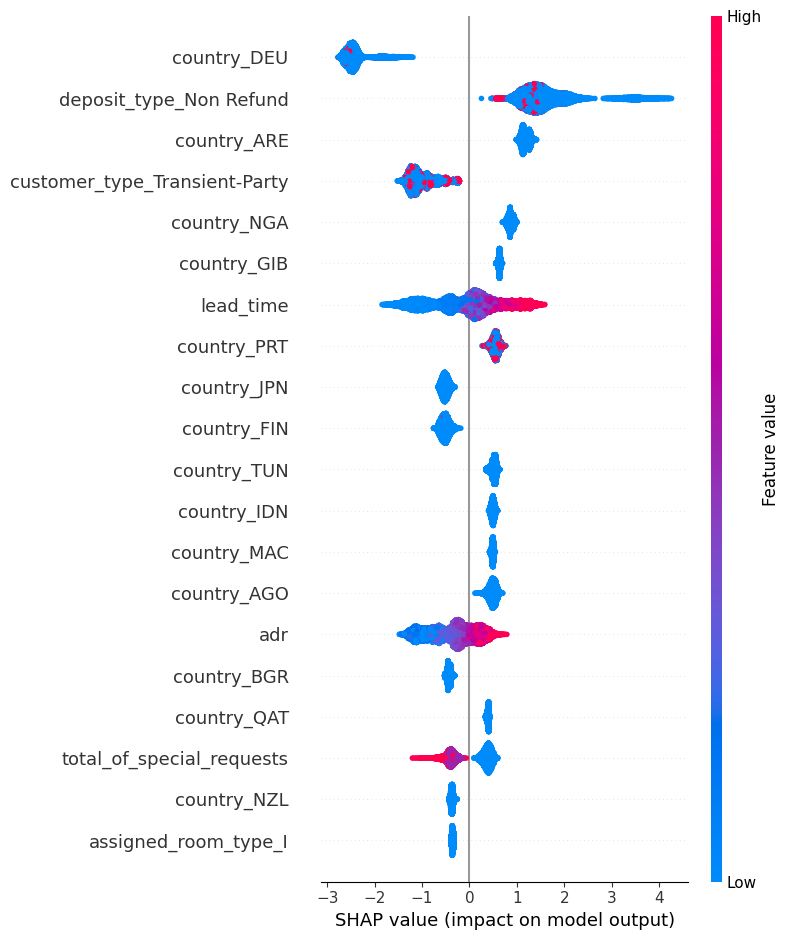

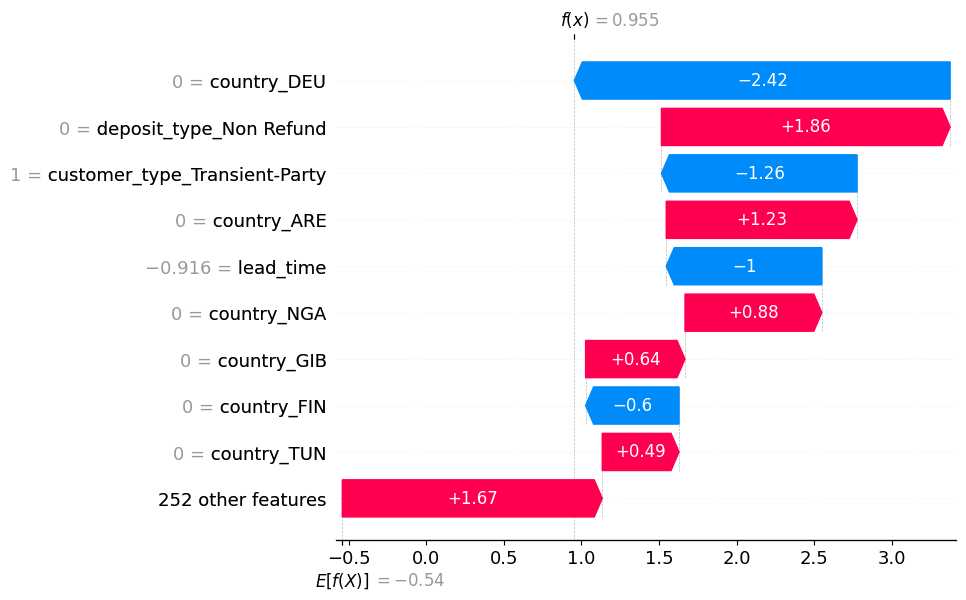

In [22]:
shap.summary_plot(shap_values, X_transformed, plot_type='bar')
shap.summary_plot(shap_values, X_transformed)
shap.waterfall_plot(shap_values[1])

In [13]:
pd.set_option('display.max_columns', None)
X_transformed

,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_guests,total_nights,previous_bookings,hotel_City Hotel,hotel_Resort Hotel,arrival_date_month_April,arrival_date_month_August,arrival_date_month_December,arrival_date_month_February,arrival_date_month_January,arrival_date_month_July,arrival_date_month_June,arrival_date_month_March,arrival_date_month_May,arrival_date_month_November,arrival_date_month_October,arrival_date_month_September,meal_BB,meal_FB,meal_HB,meal_SC,meal_Undefined,country_ABW,country_AGO,country_AIA,country_ALB,country_AND,country_ARE,country_ARG,country_ARM,country_ASM,country_ATA,country_ATF,country_AUS,country_AUT,country_AZE,country_BEL,country_BEN,country_BFA,country_BGD,country_BGR,country_BHR,country_BHS,country_BIH,country_BLR,country_BOL,country_BRA,country_BRB,country_CAF,country_CHE,country_CHL,country_CHN,country_CIV,country_CMR,country_CN,country_COL,country_COM,country_CPV,country_CRI,country_CUB,country_CYM,country_CYP,country_CZE,country_DEU,country_DJI,country_DMA,country_DNK,country_DOM,country_DZA,country_ECU,country_EGY,country_ESP,country_EST,country_ETH,country_FIN,country_FJI,country_FRA,country_FRO,country_GAB,country_GBR,country_GEO,country_GGY,country_GHA,country_GIB,country_GLP,country_GNB,country_GRC,country_GTM,country_HKG,country_HND,country_HRV,country_HUN,country_IDN,country_IMN,country_IND,country_IRL,country_IRN,country_IRQ,country_ISL,country_ISR,country_ITA,country_JAM,country_JEY,country_JOR,country_JPN,country_KAZ,country_KEN,country_KHM,country_KNA,country_KOR,country_KWT,country_LAO,country_LBN,country_LBY,country_LIE,country_LKA,country_LTU,country_LUX,country_LVA,country_MAC,country_MAR,country_MCO,country_MDG,country_MDV,country_MEX,country_MKD,country_MLI,country_MLT,country_MMR,country_MNE,country_MOZ,country_MRT,country_MUS,country_MWI,country_MYS,country_MYT,country_NAM,country_NCL,country_NGA,country_NIC,country_NLD,country_NOR,country_NPL,country_NZL,country_OMN,country_PAK,country_PAN,country_PER,country_PHL,country_PLW,country_POL,country_PRI,country_PRT,country_PRY,country_PYF,country_QAT,country_ROU,country_RUS,country_RWA,country_SAU,country_SDN,country_SEN,country_SGP,country_SLE,country_SLV,country_SMR,country_SRB,country_STP,country_SUR,country_SVK,country_SVN,country_SWE,country_SYC,country_SYR,country_TGO,country_THA,country_TJK,country_TMP,country_TUN,country_TUR,country_TWN,country_TZA,country_UGA,country_UKR,country_UMI,country_URY,country_USA,country_UZB,country_Unknown,country_VEN,country_VGB,country_VNM,country_ZAF,country_ZMB,country_ZWE,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,reserved_room_type_A,reserved_room_type_B,reserved_room_type_C,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_L,reserved_room_type_P,assigned_room_type_A,assigned_room_type_B,assigned_room_type_C,assigned_room_type_D,assigned_room_type_E,assigned_room_type_F,assigned_room_type_G,assigned_room_type_H,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L,assigned_room_type_P,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Contract,customer_type_Group,customer_type_Transient,customer_type_Transient-Party,is_repeated_guest_0,is_repeated_guest_1,has_company_0,has_company_1,has_agent_0,has_agent_1,room_changed_0,room_changed_1
0,-0.841025,-0.221372,0.211021,0.591461,-0.928908,-0.261137,0.246367,-0.259968,-0.07886